# Matplotlib Like a Pro

## Matplotlib Is a Drawing Tool

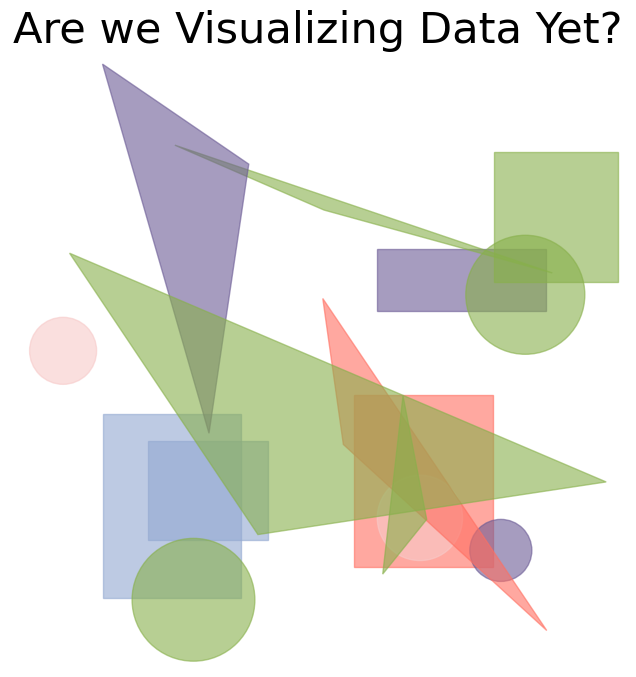

In [1]:
import matplotlib.pyplot as plt
from matplotlib import patches
from numpy.random import default_rng
from numpy import column_stack

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Define colors and shapes
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1']
rng = default_rng(7)

# Draw rectangles
for _ in range(5):
    width, height = rng.uniform(1, 3, size=2)
    x, y = rng.uniform(0, 10 - max(width, height), size=2)
    color = rng.choice(colors)
    rect = patches.Rectangle((x, y), width, height, color=color, alpha=0.6)
    ax.add_patch(rect)

# Draw circles
for _ in range(5):
    radius = rng.uniform(0.5, 1.5)
    x, y = rng.uniform(radius, 10 - radius, size=2)
    color = rng.choice(colors)
    circle = patches.Circle((x, y), radius, color=color, alpha=0.6)
    ax.add_patch(circle)

# Draw triangles
for _ in range(5):
    x, y = rng.uniform(0, 10, size=(2, 3))
    color = rng.choice(colors)
    polygon = patches.Polygon(column_stack([x, y]), color=color, alpha=0.6)
    ax.add_patch(polygon)


ax.set_title('Are we Visualizing Data Yet?', size='xx-large')

plt.show()

Matplotlib lets you achieve an arbitrary level of precision for your charts.
Want to draw something anywhere on any chart? There’s an API for that, you
just need to know where to start looking.

- Matplotlib is 20 years old; historical baggage.
- Seaborn, Plotly, Altair

- Polars was much cleaner/succinct


## Some Data

In [2]:
from numpy.random import default_rng
from pandas import DataFrame
import numpy as np

rng = default_rng(0)

n_subjects_per_group = 10
groups = ['control', 'treatment']
trial_types = ['normal', 'impacted']

subject_ids = [f's{i}' for i in range(n_subjects_per_group * len(groups))]
group_labels = np.repeat(groups, n_subjects_per_group)

trials = [rng.choice(trial_types) for _ in range(100)]

rows = []
for sid, group in zip(subject_ids, group_labels):
    for trial_n, trial_type in enumerate(trials, 1):
        bloc = 5 if group == 'control' else 6
        wloc = 1 if trial_type == 'normal' else 1.5
        value = rng.normal(loc=bloc*wloc, scale=2)
        rows.append({
            'sid': sid,
            'group': group,
            'trial_type': trial_type,
            'trial_n': trial_n,
            'value': value
        })

df = DataFrame(rows)
df.to_csv('data.csv', index=False)
print(df)

      sid      group trial_type  trial_n     value
0      s0    control   impacted        1  8.214761
1      s0    control   impacted        2  5.083363
2      s0    control   impacted        3  7.491092
3      s0    control     normal        4  6.312950
4      s0    control     normal        5  2.423277
...   ...        ...        ...      ...       ...
1995  s19  treatment   impacted       96  7.908268
1996  s19  treatment     normal       97  6.373168
1997  s19  treatment     normal       98  6.615350
1998  s19  treatment     normal       99  7.603201
1999  s19  treatment   impacted      100  9.250043

[2000 rows x 5 columns]


```
|-----||--|
| A   ||B |
|-----||--|
|-----|
| C   |
|-----|
```

- A → (lines)   Avg. Trial Performance For Group
- B → (density) Spread of Group Performance
- C → (bar)     Sorted Avg Trial Performance For Group

## Now We’re Visualizing Data

Todos
- simple annotations
- removing legends
- spans & highlighting?

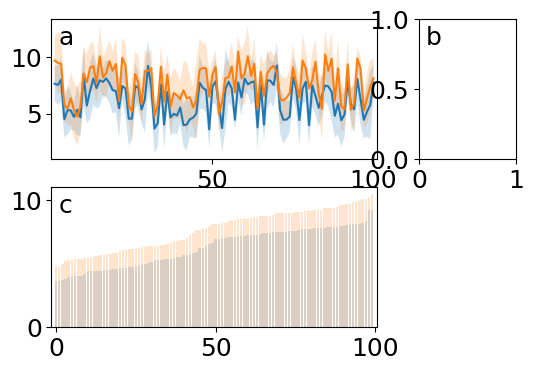

In [3]:
from pandas import read_csv
from matplotlib.pyplot import subplots, subplot_mosaic, show

df = read_csv('data.csv')

mosaic = [
    ['a', 'b'],
    ['c', '.']
]

fig, axd = subplot_mosaic(mosaic, gridspec_kw={'width_ratios': [1, .3]})

# data space
# proportion space
# mix and match coord systems: data on the x, but proprotion on y
# …

for label, ax in axd.items():
    # ax.text(x=0.05, y=.95, s=label, transform=ax.transAxes)
    ax.annotate(
        label,
        xy=(0, 1), xycoords=ax.transAxes,
        xytext=(5, -5), textcoords='offset points',
        va='top',
    )

agg = df.groupby(['group', 'trial_type', 'trial_n'])['value'].agg(['mean', 'std'])

for g_label, group in agg.groupby(['group']):
    group = group.reset_index()
    groups_strial = group.sort_values('trial_n')
    axd['a'].plot(groups_strial['trial_n'], groups_strial['mean'])
    axd['a'].fill_between(
        groups_strial['trial_n'],
        groups_strial['mean'] + groups_strial['std'],
        groups_strial['mean'] - groups_strial['std'],
        alpha=.2
    )

    groups_svalue = group.sort_values('mean')
    axd['c'].bar(range(len(groups_svalue['trial_n'])), groups_svalue['mean'], alpha=.2)

    for axlabel in ['a', 'c']:
        axd[axlabel].margins(x=.01)

show()